In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

DATA_DIR = Path("C:/SmartMeal/data/usda")
DATA_DIR.mkdir(exist_ok=True)

print("✅ Imports OK")

✅ Imports OK


In [14]:
# Données USDA pour 100g — sources vérifiées
nutrition_data = [
    {"class_name": "pizza",          "calories": 266, "protein_g": 11.0, "fat_g": 10.0, "carbs_g": 33.0, "fiber_g": 2.3, "sugar_g": 3.6,  "sodium_mg": 598},
    {"class_name": "sushi",          "calories": 143, "protein_g": 5.8,  "fat_g": 3.2,  "carbs_g": 21.0, "fiber_g": 0.6, "sugar_g": 5.0,  "sodium_mg": 367},
    {"class_name": "hamburger",      "calories": 295, "protein_g": 17.0, "fat_g": 14.0, "carbs_g": 24.0, "fiber_g": 1.3, "sugar_g": 6.0,  "sodium_mg": 396},
    {"class_name": "caesar_salad",   "calories": 190, "protein_g": 8.0,  "fat_g": 15.0, "carbs_g": 8.0,  "fiber_g": 2.0, "sugar_g": 2.0,  "sodium_mg": 420},
    {"class_name": "steak",          "calories": 271, "protein_g": 26.0, "fat_g": 18.0, "carbs_g": 0.0,  "fiber_g": 0.0, "sugar_g": 0.0,  "sodium_mg": 60},
    {"class_name": "apple_pie",      "calories": 237, "protein_g": 2.0,  "fat_g": 11.0, "carbs_g": 34.0, "fiber_g": 1.5, "sugar_g": 16.0, "sodium_mg": 169},
    {"class_name": "omelette",       "calories": 154, "protein_g": 10.0, "fat_g": 12.0, "carbs_g": 1.0,  "fiber_g": 0.0, "sugar_g": 0.5,  "sodium_mg": 300},
    {"class_name": "grilled_salmon", "calories": 208, "protein_g": 20.0, "fat_g": 13.0, "carbs_g": 0.0,  "fiber_g": 0.0, "sugar_g": 0.0,  "sodium_mg": 59},
    {"class_name": "ice_cream",      "calories": 207, "protein_g": 3.5,  "fat_g": 11.0, "carbs_g": 24.0, "fiber_g": 0.0, "sugar_g": 21.0, "sodium_mg": 80},
    {"class_name": "bibimbap",       "calories": 490, "protein_g": 26.0, "fat_g": 12.0, "carbs_g": 69.0, "fiber_g": 4.0, "sugar_g": 6.0,  "sodium_mg": 890},
]

df_nutrition = pd.DataFrame(nutrition_data)
print("✅ Données nutritionnelles chargées")
print(f"📊 Shape : {df_nutrition.shape}")
print(f"\n{df_nutrition[['class_name','calories','protein_g','fat_g','carbs_g']].to_string(index=False)}")

✅ Données nutritionnelles chargées
📊 Shape : (10, 8)

    class_name  calories  protein_g  fat_g  carbs_g
         pizza       266       11.0   10.0     33.0
         sushi       143        5.8    3.2     21.0
     hamburger       295       17.0   14.0     24.0
  caesar_salad       190        8.0   15.0      8.0
         steak       271       26.0   18.0      0.0
     apple_pie       237        2.0   11.0     34.0
      omelette       154       10.0   12.0      1.0
grilled_salmon       208       20.0   13.0      0.0
     ice_cream       207        3.5   11.0     24.0
      bibimbap       490       26.0   12.0     69.0


C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:38: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:38: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:38: UserWarning: Glyph 129474 (\N{SALT SHAKER}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:39: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  plt.savefig("C:/SmartMeal/reports/nutrition_profile.png", dpi=150)
C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:39: UserWarning: Glyph 127807 (\N{HERB}) missing from font(s) DejaVu Sans.
  plt.savefig("C:/SmartMeal/reports/nutrition_profile.png", dpi=150)
C:\Users\pc\AppData\Local\Temp\ipykernel_880\444839579.py:39: UserWarning: Glyph 129474 (\N{SALT SHAKER}) missing from font(s) 

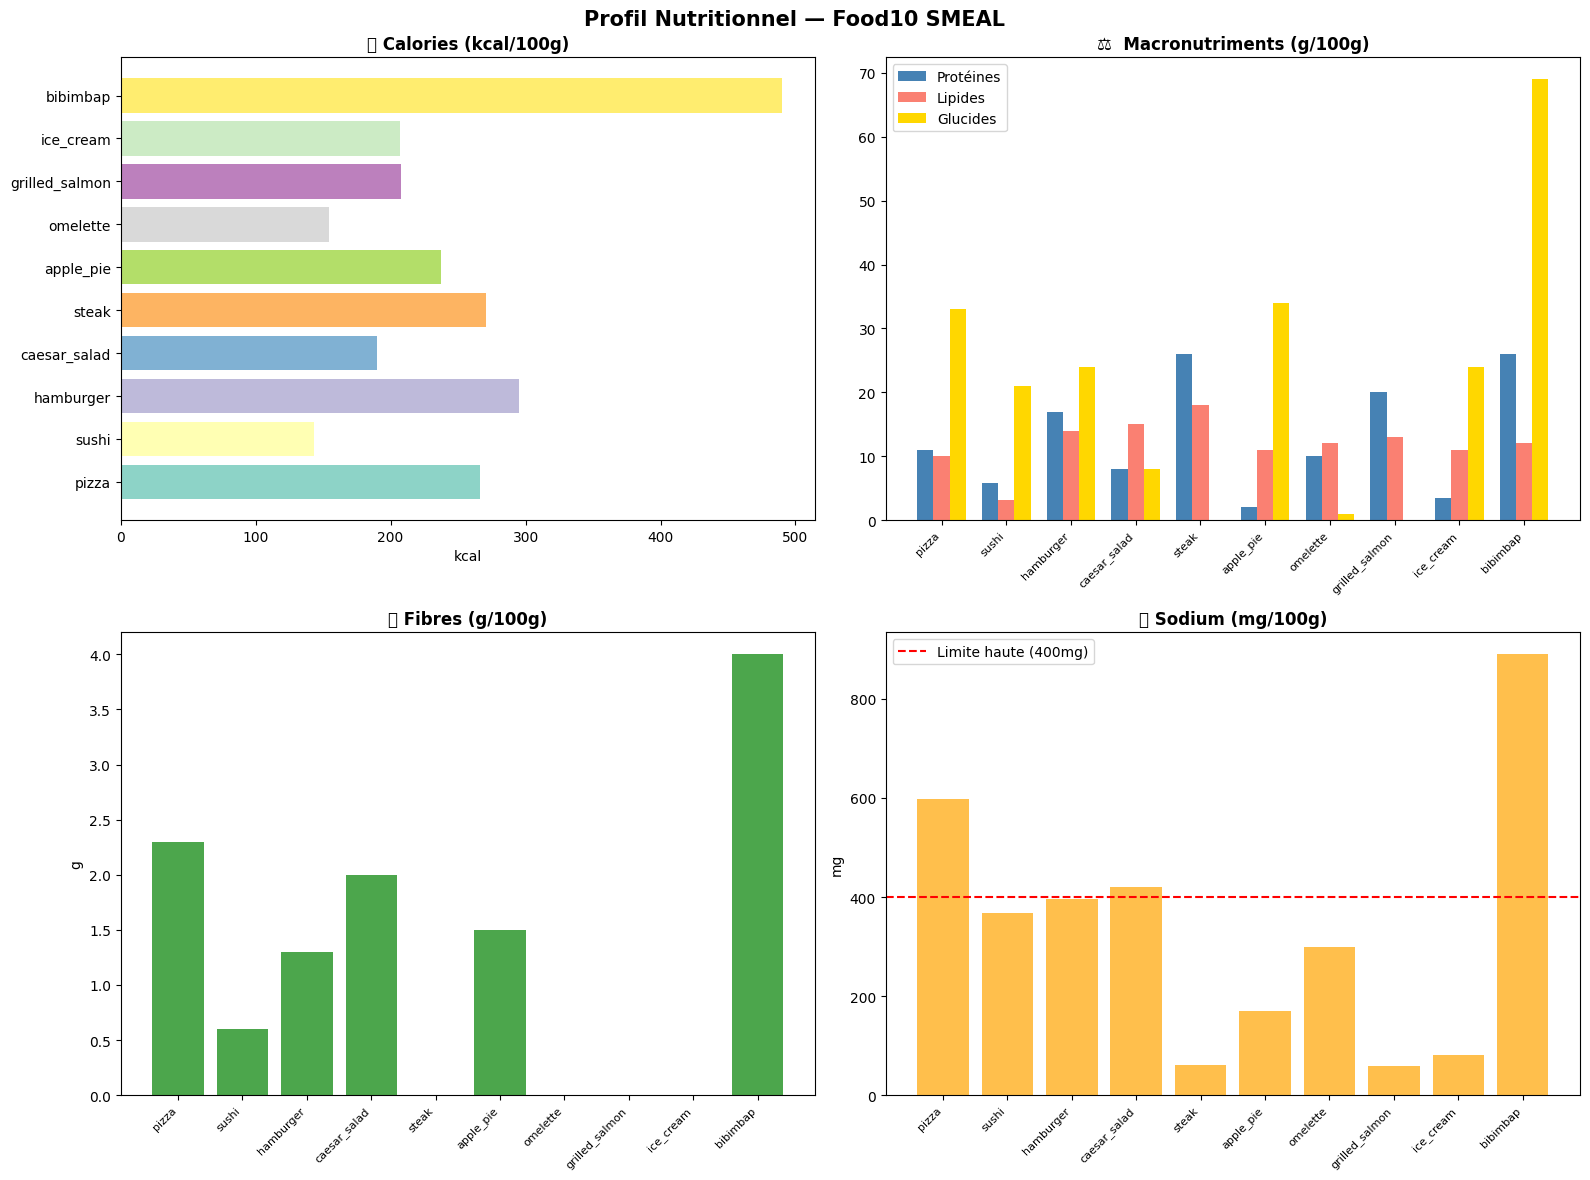

✅ Visualisation sauvegardée


In [15]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
df_plot   = df_nutrition.set_index("class_name")
colors    = plt.cm.Set3(np.linspace(0, 1, len(df_plot)))

# ── Calories ─────────────────────────────────────────────
axes[0,0].barh(df_plot.index, df_plot["calories"], color=colors)
axes[0,0].set_title("🔥 Calories (kcal/100g)", fontweight="bold")
axes[0,0].set_xlabel("kcal")

# ── Macronutriments ──────────────────────────────────────
x     = np.arange(len(df_plot))
width = 0.25
axes[0,1].bar(x - width, df_plot["protein_g"], width, label="Protéines", color="steelblue")
axes[0,1].bar(x,         df_plot["fat_g"],     width, label="Lipides",   color="salmon")
axes[0,1].bar(x + width, df_plot["carbs_g"],   width, label="Glucides",  color="gold")
axes[0,1].set_xticks(x)
axes[0,1].set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=8)
axes[0,1].set_title("⚖️  Macronutriments (g/100g)", fontweight="bold")
axes[0,1].legend()

# ── Fibres ───────────────────────────────────────────────
axes[1,0].bar(df_plot.index, df_plot["fiber_g"], color="green", alpha=0.7)
axes[1,0].set_xticks(range(len(df_plot)))
axes[1,0].set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=8)
axes[1,0].set_title("🌿 Fibres (g/100g)", fontweight="bold")
axes[1,0].set_ylabel("g")

# ── Sodium ───────────────────────────────────────────────
axes[1,1].bar(df_plot.index, df_plot["sodium_mg"], color="orange", alpha=0.7)
axes[1,1].axhline(y=400, color="red", linestyle="--", label="Limite haute (400mg)")
axes[1,1].set_xticks(range(len(df_plot)))
axes[1,1].set_xticklabels(df_plot.index, rotation=45, ha="right", fontsize=8)
axes[1,1].set_title("🧂 Sodium (mg/100g)", fontweight="bold")
axes[1,1].set_ylabel("mg")
axes[1,1].legend()

plt.suptitle("Profil Nutritionnel — Food10 SMEAL", fontsize=15, fontweight="bold")
plt.tight_layout()
plt.savefig("C:/SmartMeal/reports/nutrition_profile.png", dpi=150)
plt.show()
print("✅ Visualisation sauvegardée")

In [16]:
csv_path = Path("C:/SmartMeal/data/usda/nutrition_food10.csv")
df_nutrition.to_csv(csv_path, index=False)

print(f"✅ CSV sauvegardé : {csv_path}")
print(f"\n🎯 Résumé :")
print(f"   Plus calorique  : {df_nutrition.loc[df_nutrition['calories'].idxmax(), 'class_name']} "
      f"({df_nutrition['calories'].max()} kcal)")
print(f"   Moins calorique : {df_nutrition.loc[df_nutrition['calories'].idxmin(), 'class_name']} "
      f"({df_nutrition['calories'].min()} kcal)")
print(f"   + protéines     : {df_nutrition.loc[df_nutrition['protein_g'].idxmax(), 'class_name']} "
      f"({df_nutrition['protein_g'].max()}g)")
print(f"   + fibres        : {df_nutrition.loc[df_nutrition['fiber_g'].idxmax(), 'class_name']} "
      f"({df_nutrition['fiber_g'].max()}g)")
print(f"   + sodium        : {df_nutrition.loc[df_nutrition['sodium_mg'].idxmax(), 'class_name']} "
      f"({df_nutrition['sodium_mg'].max()}mg)")

✅ CSV sauvegardé : C:\SmartMeal\data\usda\nutrition_food10.csv

🎯 Résumé :
   Plus calorique  : bibimbap (490 kcal)
   Moins calorique : sushi (143 kcal)
   + protéines     : steak (26.0g)
   + fibres        : bibimbap (4.0g)
   + sodium        : bibimbap (890mg)
